# Lab 5-1: Model Selection: Classification

## Data

We will use Mortgage Affordability data from Zillow to experiment with classification algorithms. The data was downloaded from [Zillow Research](https://www.zillow.com/research/data/) page. Please download the Affordability_Wide_2017Q4_Public.csv file to your project directory.

## Preparing the data

First, we will tidy the data. Please include this piece of code in your submission.

In [42]:
import pandas as pd
import numpy as np
from plotnine import *

theme_set(theme_bw())

In [43]:
# Read and prepare data

df = (pd.read_csv('Affordability_Wide_2017Q4_Public.csv')
        .query('Index == "Mortgage Affordability" and SizeRank != 0')
        .drop(columns=['Index', 'HistoricAverage_1985thru1999','SizeRank'])
        .dropna()
        .melt(id_vars=['RegionID','RegionName'],
              var_name='time', value_name='affordability'))
df['time'] = pd.to_datetime(df.time, format="%Y-%m")
df.head()

,RegionID,RegionName,time,affordability
0,394913,"New York, NY",1979-03-01,0.261700
1,753899,"Los Angeles-Long Beach-Anaheim, CA",1979-03-01,0.357694
2,394463,"Chicago, IL",1979-03-01,0.261928
3,394514,"Dallas-Fort Worth, TX",1979-03-01,0.301131
4,394974,"Philadelphia, PA",1979-03-01,0.204333


This is what the data looks like:

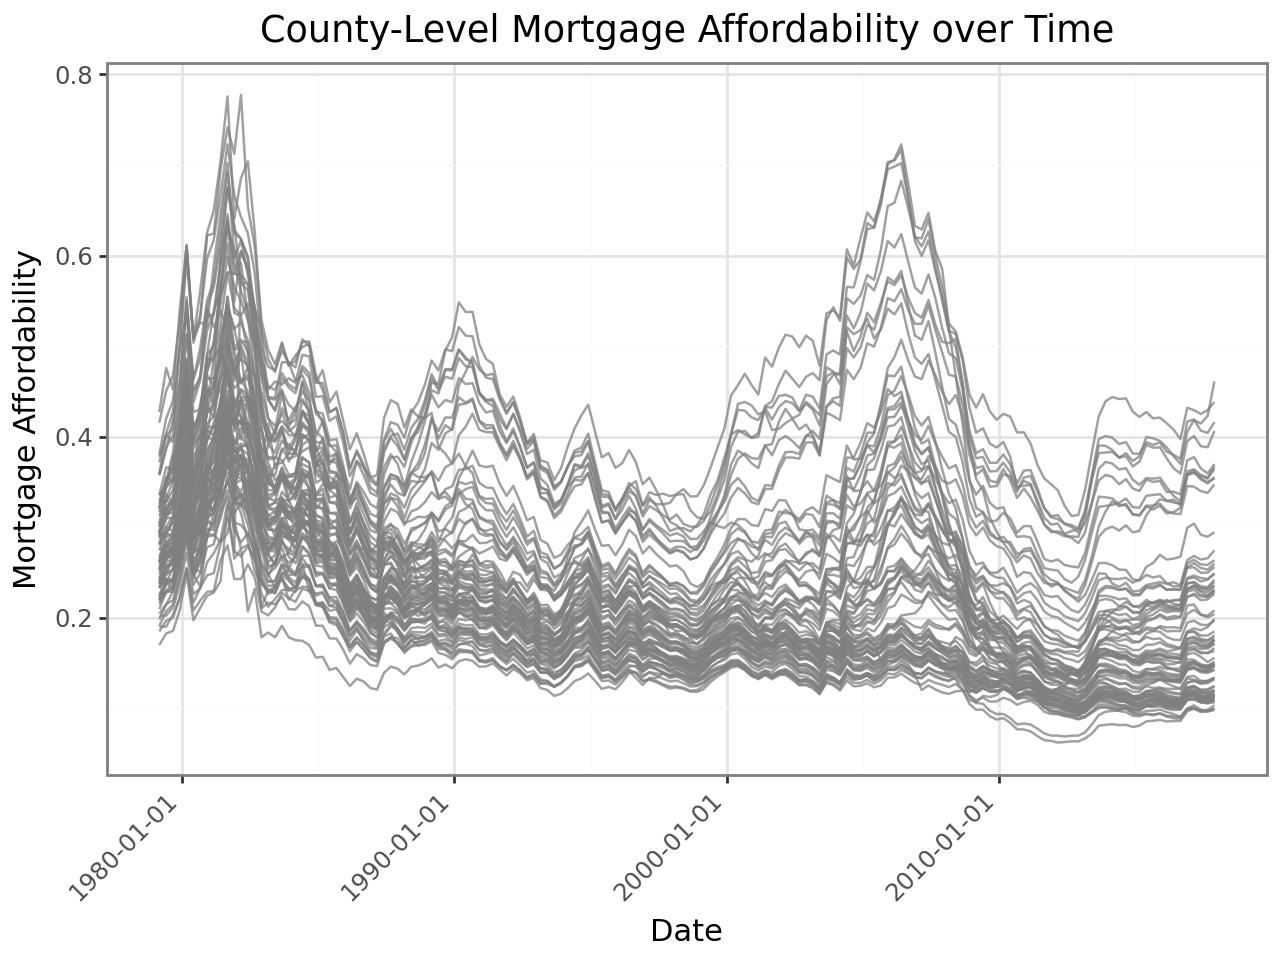

In [44]:
# plot data

(ggplot(df, aes(x='time', y='affordability', group='factor(RegionID)')) +
  geom_line(color="GRAY", alpha=3/4, size=1/2) +
  theme(axis_text_x=element_text(angle=45,hjust=1)) +
  labs(title="County-Level Mortgage Affordability over Time",
          x="Date", y="Mortgage Affordability"))

## The prediction task

The prediction task we are going to answer is: `Can we predict if mortgage affordability will increase or decrease a year from now?` Specifically, we will do this for quarter 4 (Q4) of 2017. To create the prediction outcome, we will compare affordability for Q4 of 2017 to Q4 of 2016 and label it as `up` or `down`, depending on the sign of the this difference. Let's create the outcome we want to predict (again, copy this bit of code to your submission):

In [45]:
outcome_dates = ['2016-12-01', '2017-12-01']
outcome_df = (df.query('time in @outcome_dates')
   .pivot(index='RegionID', columns='time', values='affordability'))

outcome_df['diff'] = outcome_df['2017-12-01'] - outcome_df['2016-12-01']
outcome_df['Direction'] = 'Down'
outcome_df['Direction'] = outcome_df['Direction'].where(outcome_df['diff'] < 0, 'Up') # this replaces where conditions is False
outcome_df = outcome_df.reset_index()[['RegionID','Direction']]
outcome_df.head()

/tmp/ipykernel_2315/2794282039.py:2: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.


time,RegionID,Direction
0,394304,Down
1,394312,Down
2,394318,Down
3,394347,Up
4,394355,Up


Now you have a dataframe with outcomes (labels) for each county in the dataset. The goal is then:  given predictors $X_i$ for county $i$, build a classifier for outcome $G_i \in \{\mathtt{up},\mathtt{down}\}$.

To train your classifiers you should use data up to 2016:

In [46]:
predictor_df = df.query('time < 20170101')


# An example experiment

Question: Does the number of trees used in a random forest classifier affect performance (AUROC measured with 5-fold CV)?

Other decisions: We are transforming input data to use quarterly differences after data standardization for years 2014-2016.

## Data preparation

First, filter to the years of interest and standardize affordability for each region.

In [47]:
# Subset data and compute mean and standard deviation per region
tmp_df = predictor_df.query('time > 20131201 & time < 20170101')
stat_df = tmp_df.groupby('RegionID').agg({'affordability': ['mean', 'std']})
stat_df.columns = stat_df.columns.get_level_values(1)
stat_df.reset_index(col_level=1).set_index('RegionID')

# Standardize affordability for each region
std_df = tmp_df.set_index('RegionID').join(stat_df)
std_df['std_affordability'] = (std_df['affordability'] - std_df['mean'])/std_df['std']
std_df.head()

,RegionName,time,affordability,mean,std,std_affordability
RegionID,,,,,,
394913,"New York, NY",2014-03-01,0.258141,0.246122,0.008536,1.408150
753899,"Los Angeles-Long Beach-Anaheim, CA",2014-03-01,0.398916,0.390070,0.011075,0.798722
394463,"Chicago, IL",2014-03-01,0.141666,0.136329,0.004224,1.263667
394514,"Dallas-Fort Worth, TX",2014-03-01,0.123380,0.127295,0.007789,-0.502663
394974,"Philadelphia, PA",2014-03-01,0.152352,0.143662,0.005178,1.678264


To train our model we need a table with one row per region, and attributes corresponding to differences in quarterly affordability. We will do this in stages, first we turn the tidy dataset into a wide dataset using `pd.pivot` then create a dataframe containing the differences we use as features.

In [48]:
# Switch to a 'wide' data frame
std_df['RegionID'] = std_df.index
std_df = (std_df[['RegionID','time','std_affordability']]
  .pivot(index='RegionID', columns='time', values='std_affordability'))

# Construct matrix of quarterly differences
mat1 = std_df.iloc[:,1:].to_numpy()
mat2 = std_df.iloc[:,:-1].to_numpy()
X = mat1 - mat2

# Get the outcome from the dataframe we created
outcome_df['y'] = 0
outcome_df['y'] = outcome_df['y'].where(outcome_df['Direction'] == "Down", 1)
y = outcome_df['y'].to_numpy()

## Run the experiment

We will only use 5-fold cross-validation to compare a random forest with 500 trees, with a random forest with 10 trees. Since this is a smallish dataset,  we are using 5-fold cross validation to make the validation sets have more examples and therefore more reliable performance estimates.

In [49]:
import sklearn.ensemble
import sklearn.model_selection
import sklearn.metrics
import matplotlib.pylab as plt
import numpy as np

In [50]:
small_rf = sklearn.ensemble.RandomForestClassifier(n_estimators=10)
big_rf = sklearn.ensemble.RandomForestClassifier(n_estimators=500)

parameters = {'max_features': [2,6,11]} # we do this to match what the R version did
small_cv = sklearn.model_selection.GridSearchCV(small_rf, parameters, cv=5)
big_cv = sklearn.model_selection.GridSearchCV(big_rf, parameters, cv=5)

# Following sklearn tutorial
# https://scikit-learn.org/stable/auto_examples/model_selection/plot_roc_crossval.html#sphx-glr-auto-examples-model-selection-plot-roc-crossval-py
cv_obj = sklearn.model_selection.StratifiedKFold(n_splits=5)


def get_roc_data(model, cv_obj):
    curve_df = None
    aucs = []
    mean_fpr = np.linspace(0, 1, 100)

    for i, (train, test) in enumerate(cv_obj.split(X, y)):
        model.fit(X[train], y[train])
        scores = model.predict_proba(X[test])[:,1]
        fpr, tpr, _ = sklearn.metrics.roc_curve(y[test],scores)

        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0.0
        tmp = pd.DataFrame({'fold':i, 'fpr': mean_fpr, 'tpr': interp_tpr})
        curve_df = tmp if curve_df is None else pd.concat([curve_df, tmp])

        aucs.append(sklearn.metrics.auc(fpr, tpr))

    curve_df = curve_df.groupby('fpr').agg({'tpr': 'mean'}).reset_index()
    curve_df.iloc[-1,1] = 1.0

    auc_df = pd.DataFrame({'fold': np.arange(len(aucs)), 'auc': aucs})
    return curve_df, auc_df

In [51]:
# Get ROC curve data for small model
small_curve_df, small_auc_df = get_roc_data(small_cv, cv_obj)
small_curve_df['model'] = 'small'
small_auc_df['model'] = 'small'

In [52]:
# Get ROC curve data for big model
big_curve_df, big_auc_df = get_roc_data(big_cv, cv_obj)
big_curve_df['model'] = 'big'
big_auc_df['model'] = 'big'

In [53]:
# Combine the ROC curve data
curve_df = pd.concat([small_curve_df, big_curve_df])
auc_df = pd.concat([small_auc_df, big_auc_df])

auc_df

,fold,auc,model
0,0,0.525000,small
1,1,0.500000,small
2,2,0.758333,small
3,3,0.541667,small
4,4,0.563636,small
0,0,0.350000,big
1,1,0.533333,big
2,2,0.666667,big
3,3,0.491667,big
4,4,0.654545,big


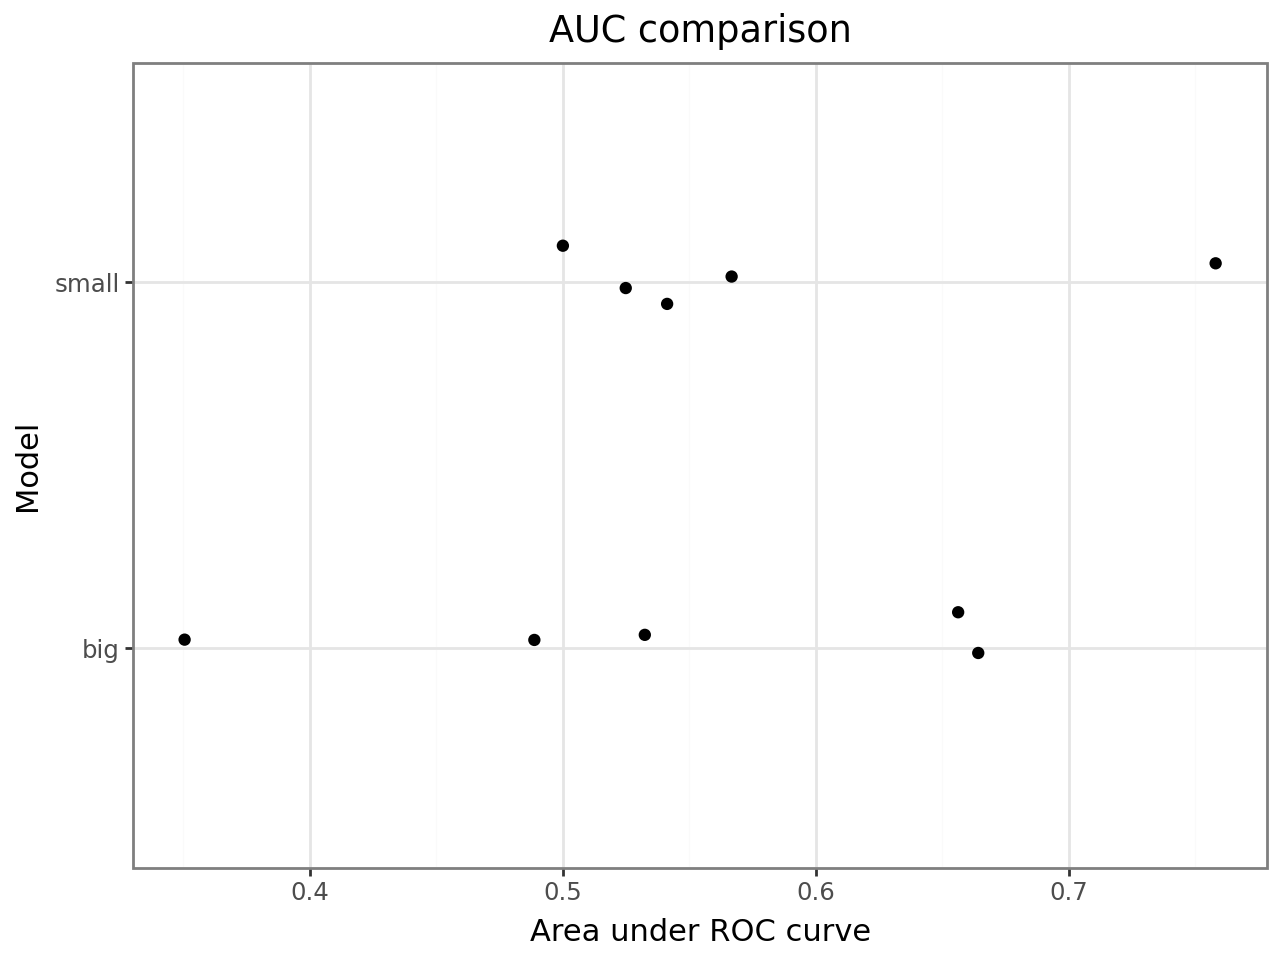

In [54]:
# Plot the distribution of auc estimates
(ggplot(auc_df, aes(x='model', y='auc')) +
     geom_jitter(position=position_jitter(0.1)) +
     coord_flip() +
     labs(title = "AUC comparison",
          x="Model",
          y="Area under ROC curve"))

We can also test for differences using linear regression:

In [55]:
# Use a two-sided test (based on linear regression) to see if there is a
# statistically significant difference in auc estimates
import statsmodels.formula.api as smf
lm_fit = smf.ols('auc~model', data=auc_df).fit()

In [56]:
lm_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    auc   R-squared:                       0.032
Model:                            OLS   Adj. R-squared:                 -0.089
Method:                 Least Squares   F-statistic:                    0.2679
Date:                Fri, 24 Apr 2026   Prob (F-statistic):              0.619
Time:                        02:40:41   Log-Likelihood:                 8.3335
No. Observations:                  10   AIC:                            -12.67
Df Residuals:                       8   BIC:                            -12.06
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          0.5392      0.053     10.256      0.000       0.418       0.660
model[T.small]     0.0385      0.074      0.518      0.619      -0.133       0.210
==============================================================================
Omnibus:                        0.089   Durbin-Watson:                   2.297
Prob(Omnibus):                  0.956   Jarque-Bera (JB):                0.239
Skew:                           0.167   Prob(JB):                        0.888
Kurtosis:                       2.321   Cond. No.                         2.62
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

There is a small decrease (2.8%) in average AUROC for the small model but it is not a statistically significant difference.

Finally, here are the ROC curves for both models:

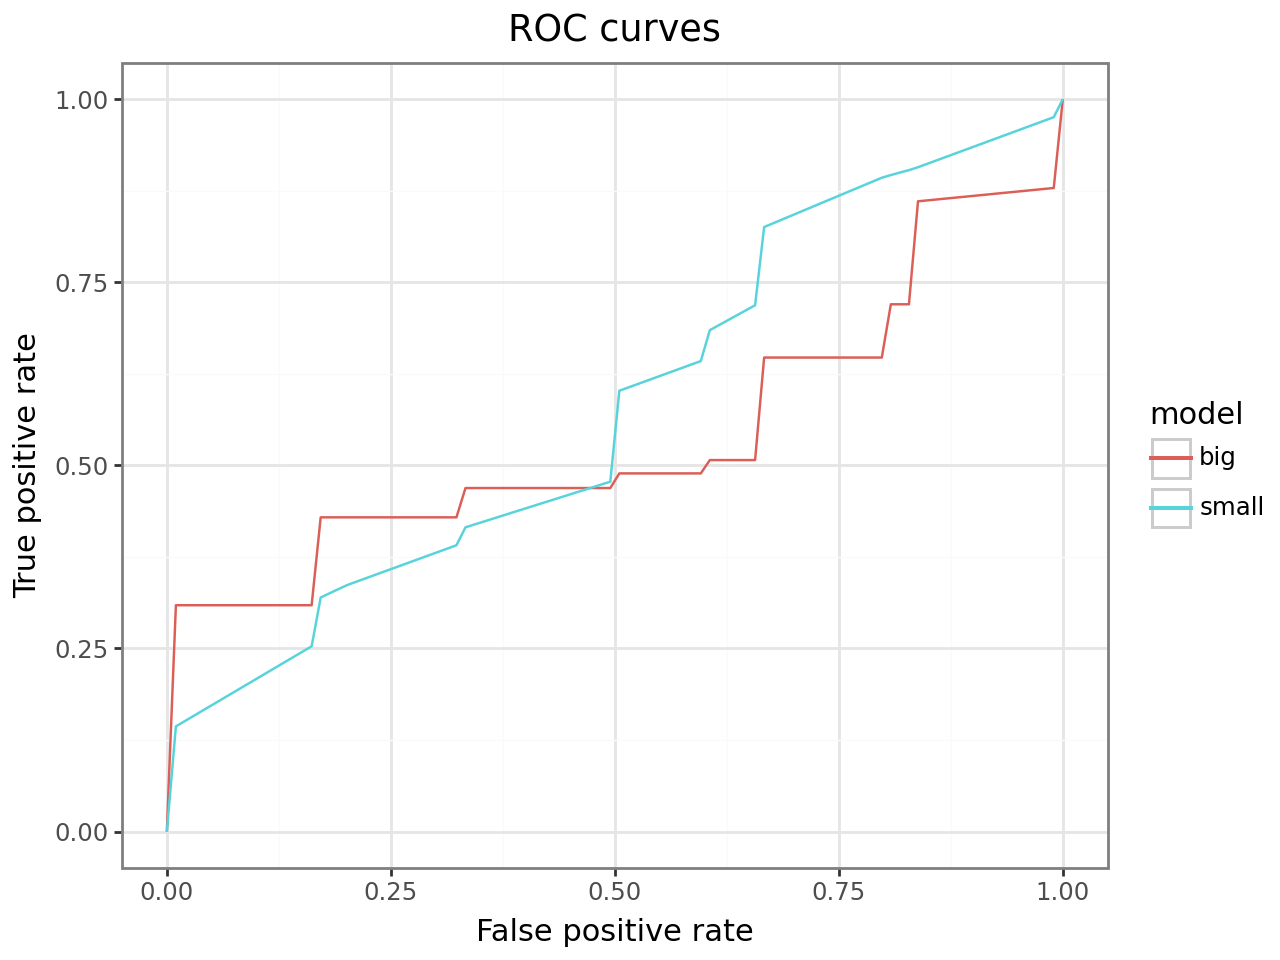

In [57]:
mean_curve_df = curve_df.groupby(['model','fpr']).agg({'tpr': 'mean'}).reset_index()
(ggplot(mean_curve_df, aes(x='fpr', y='tpr', color='model')) +
    geom_line() +
    labs(title = "ROC curves",
         x = "False positive rate",
         y = "True positive rate"))

There is a small difference in the low false positive rate between the models but, essentially, these models perform very similarly. Neither model is very good at this task apparently.

## Your Project's Goal
Your goal for this project is to do an experiment to address a (one, single) technical question about our ability to make this prediction. Here is a list of possible questions you may address below. Each of them asks to compare two specific choices in the classification workflow (e.g., two classification algorithms, two feature representations, etc.).

You will *implement* each of the two choices and use *10-fold cross validation* (across RegionID's) to compare their relative performance. You will also create an *AUROC curve* to compare them.

## Possible Questions

### Feature representation and preprocessing
- Does standardizing affordability for each region affect  prediction performance? Compare standardized to non-standardized affordability.
- Is using quarter to quarter change (continuous or discrete) improve prediction performance? Compare quarter to quarter change in affordability as predictors to affordability as predictor?
- Should we use the full time series for each region, or should we use only the last few years? Compare full time series to a subset of the time series?
- Should we expand the training set to multiple time series per region? For example, create a similar outcome for each time point in the dataset (change relative to affordability one year ago) and use data from the last couple of years as predictors. Train on the extended dataset and test on the 2017 data above?
- Should we do dimensionality reduction (PCA) and use the embedded data to do prediction?

*Create your own question!*

### Classification Algorithm

- Is a decision tree better than logistic regression?
- Is a random forest better than a decision tree?
- Is k-nearest neighbors better than a random forest?

*Create your own question!*

Note that you still have to make some choices regardless of the question you choose. For example, to do the feature preprocessing and representation experiments you have to choose a classifier (random forest for example), and decide what to do about hyper-parameters if appropriate.

# Submission
Prepare a Jupyter/IPython notebook that which includes:

1. Code to prepare data (copied from chunks above), plus any additional data prep for your experiment
2. Discussion of the question you have chosen to address, including discussion of other choices you have made (e.g., feature representation, classification algorithm) to carry out your experiment
3. Code to carry out your cross-validation experiment
4. Table (result of hypothesis testing difference between algorithms) and plot comparing AUROCs
	* ROC curves for both experimental settings
5. Interpretation and discussion of your experimental results



# Answer

### Experimental Question: Is a Decision Tree better than Logistic Regression?

**Hypothesis:**
Decision Tree might perform better than Logistic Regression for predicting mortgage affordability changes. Logistic Regression assumes a linear relationship between the features and the log-odds of the outcome, non-linear relationships or threshold-based decision rules that could be present in affordability data. On the other hand, Decision Tree, is capable of learning non-linear decision boundaries and capturing interactions between features.

## Define Models and Cross-Validation Setup



In [58]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold

lr_model = LogisticRegression(random_state=42, solver='liblinear') # Set a default solver here
dt_model = DecisionTreeClassifier(random_state=42)

# Define hyperparameter grid for Logistic Regression
lr_params = {
    'solver': ['liblinear', 'lbfgs'], # to minimize the error in the model
    'C': [0.01, 0.1, 1, 10, 100] # to prevent overlifting
}

# Define hyperparameter grid for Decision Tree
dt_params = {
    'max_depth': [None, 3, 5, 10], # avoiding overlifting
    'min_samples_leaf': [1, 5, 10] # decreas the max_depth to see if simpler tree generalizes better across 10 folds.
}

# Set up 10-fold stratified cross-validation
cv_obj = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

In [59]:
# instead of run it manual to see if max_depth = 3 is better than amx_dpeth = 5
from sklearn.model_selection import GridSearchCV

# Instantiate GridSearchCV for Logistic Regression
lr_grid_search = GridSearchCV(lr_model, lr_params, cv=cv_obj, scoring='roc_auc', n_jobs=-1)

# Get ROC curve data and AUCs for Logistic Regression
lr_curve_df, lr_auc_df = get_roc_data(lr_grid_search, cv_obj)
lr_curve_df['model'] = 'LogisticRegression'
lr_auc_df['model'] = 'LogisticRegression'



In [60]:
# Instantiate GridSearchCV for Decision Tree
dt_grid_search = GridSearchCV(dt_model, dt_params, cv=cv_obj, scoring='roc_auc', n_jobs=-1)

# Get ROC curve data and AUCs for Decision Tree
dt_curve_df, dt_auc_df = get_roc_data(dt_grid_search, cv_obj)
dt_curve_df['model'] = 'DecisionTree'
dt_auc_df['model'] = 'DecisionTree'



In [61]:
# Combine the AUC dataframes
auc_df = pd.concat([lr_auc_df, dt_auc_df])

# Combine the ROC curve dataframes
curve_df = pd.concat([lr_curve_df, dt_curve_df])

print("Combined AUC dataframe:")
print(auc_df.head())
print("\nCombined Curve dataframe:")
print(curve_df.head())

Combined AUC dataframe:
   fold       auc               model
0     0  0.933333  LogisticRegression
1     1  0.800000  LogisticRegression
2     2  0.800000  LogisticRegression
3     3  0.933333  LogisticRegression
4     4  0.733333  LogisticRegression

Combined Curve dataframe:
        fpr       tpr               model
0  0.000000  0.000000  LogisticRegression
1  0.010101  0.466667  LogisticRegression
2  0.020202  0.466667  LogisticRegression
3  0.030303  0.466667  LogisticRegression
4  0.040404  0.466667  LogisticRegression


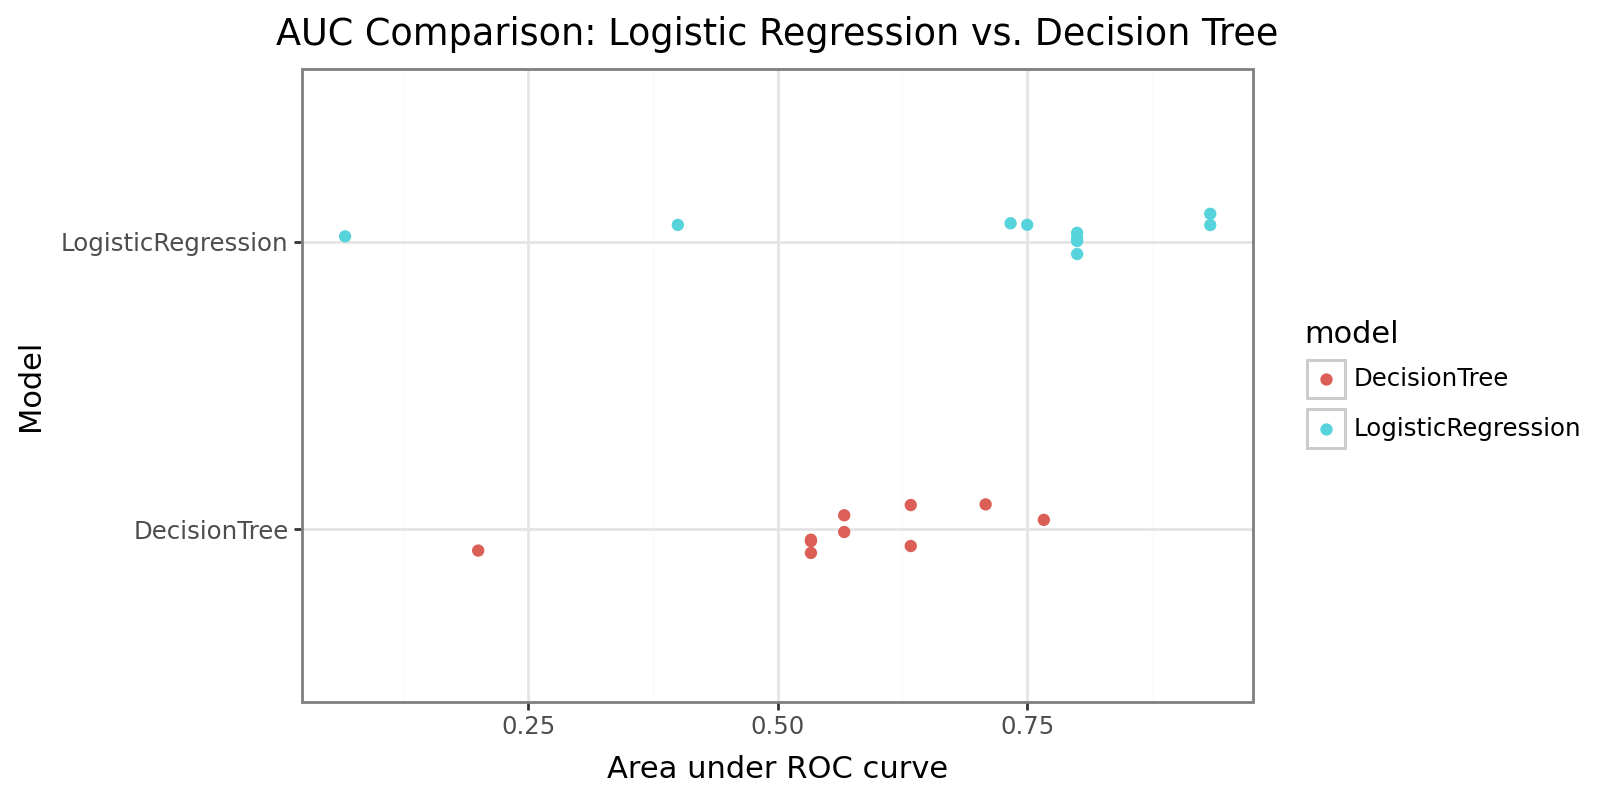

In [62]:
import plotnine

# Plot the distribution of auc estimates for both models
(ggplot(auc_df, aes(x='model', y='auc', color='model')) +
     geom_jitter(position=plotnine.position_jitter(0.1)) +
     coord_flip() +
     labs(title = "AUC Comparison: Logistic Regression vs. Decision Tree",
          x="Model",
          y="Area under ROC curve") +
     theme(figure_size=(8, 4)))


## Statistical Comparison of AUROC


In [63]:
import statsmodels.formula.api as smf

# Use a two-sided test (based on linear regression) to see if there is a
# statistically significant difference in auc estimates
lm_fit = smf.ols('auc~model', data=auc_df).fit()
lm_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    auc   R-squared:                       0.096
Model:                            OLS   Adj. R-squared:                  0.045
Method:                 Least Squares   F-statistic:                     1.905
Date:                Fri, 24 Apr 2026   Prob (F-statistic):              0.184
Time:                        02:40:55   Log-Likelihood:                 3.2001
No. Observations:                  20   AIC:                            -2.400
Df Residuals:                      18   BIC:                           -0.4087
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
===============================================================================================
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept                       0.5675      0.069      8.257      0.000       0.423       0.712
model[T.LogisticRegression]     0.1342      0.097      1.380      0.184      -0.070       0.338
==============================================================================
Omnibus:                       15.457   Durbin-Watson:                   1.734
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               14.349
Skew:                          -1.672   Prob(JB):                     0.000766
Kurtosis:                       5.457   Cond. No.                         2.62
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

#Experimental Results Summary

From the OLS Regression Results:

*   **Coefficient for `model[T.LogisticRegression]`**: `0.1342`
*   **P-value (`P>|t|`)**: `0.184` which tells if this difference real or just luck coincience. Since 0.184 > 0.05 and it makes it significant or not.

This coefficient suggests that, on average, the **Logistic Regression** model exhibited an AUROC that was approximately `0.1342` higher than the Decision Tree model.

Visually, the AUC comparison plot also suggested Logistic Regression generally performed better across the cross-validation folds.

The fact that the Decision Tree did not significantly outperform Logistic Regression might suggest a few things:

1.  The relationships between the standardized quarterly affordability differences and the direction of future affordability changes might be largely linear, or at least linear enough that the Logistic Regression model provides a reasonable approximation.
2. While GridSearchCV was used, the defined hyperparameter space for the Decision Tree (`max_depth`, `min_samples_leaf`) might not have been optimal to find the truly best performing non-linear model, potentially leading to some underfitting by the Decision Tree if the optimal depth was larger or other parameters were critical.

*   **Decision Tree**: Without further analysis of the chosen `max_depth` by `GridSearchCV` for each fold, it's hard to say definitively. However, deep decision trees are prone to overfitting. If `GridSearchCV` consistently chose shallower trees, it might have prevented overfitting but potentially led to underfitting by not capturing sufficient complexity.
*   **Logistic Regression**: Regularization (controlled by `C`) helps prevent overfitting. `GridSearchCV` should have selected an appropriate `C` value. Given its comparable performance, it likely achieved a good bias-variance trade-off within its linear constraints.

Overall, the models show a moderate ability to predict the direction of mortgage affordability, but there's room for improvement, as indicated by the average AUCs not being exceptionally high.

In [87]:
from bokeh.plotting import figure, show
from bokeh.models import ColumnDataSource

# 1. Ensure 'model' column in mean_curve_df is of string type
if mean_curve_df['model'].dtype != 'object':
    mean_curve_df['model'] = mean_curve_df['model'].astype(str)

# 2. Create a ColumnDataSource from mean_curve_df
roc_source = ColumnDataSource(mean_curve_df)

# 3. Create a separate ColumnDataSource for the diagonal reference line
dia_source = ColumnDataSource(data={'fpr': [0, 1], 'tpr': [0, 1]})

In [86]:
from bokeh.plotting import figure, show
from bokeh.models import ColumnDataSource, HoverTool
from bokeh.palettes import Category10 # Importing a palette for multiple lines

# Get the unique models for coloring and legend
models_for_plot = mean_curve_df['model'].unique()
# Manually assign colors for the two models, as Category10 does not have a key for 2
# Using colors consistent with a previous cell's palette definition
colors = ['#1f77b4', '#ff7f0e']
color_map = {model: colors[i] for i, model in enumerate(models_for_plot)}

# Initialize a Bokeh figure object
p_roc = figure(
    title="Mean ROC Curves: Logistic Regression vs. Decision Tree",
    x_axis_label="False Positive Rate",
    y_axis_label="True Positive Rate",
    x_range=(0, 1), y_range=(0, 1),
    tools="pan,wheel_zoom,box_zoom,reset,save,hover"
)

# Add a hover tool
hover = HoverTool(
    tooltips=[
        ("Model", "@model"),
        ("FPR", "@fpr{0.00}"),
        ("TPR", "@tpr{0.00}")
    ]
)
p_roc.add_tools(hover)

# Add ROC curves for each model
for i, model_name in enumerate(models_for_plot):
    # Filter the roc_source data for the current model
    model_data_indices = [j for j, model in enumerate(roc_source.data['model']) if model == model_name]
    source_subset_data = {
        'fpr': [roc_source.data['fpr'][idx] for idx in model_data_indices],
        'tpr': [roc_source.data['tpr'][idx] for idx in model_data_indices],
        'model': [model_name] * len(model_data_indices)
    }
    source_subset = ColumnDataSource(source_subset_data)

    p_roc.line(
        x='fpr',
        y='tpr',
        source=source_subset,
        legend_label=model_name,
        line_color=color_map[model_name],
        line_width=2
    )

# Add the diagonal reference line
p_roc.line(
    x='fpr',
    y='tpr',
    source=dia_source,
    legend_label="Random Classifier",
    line_color="gray",
    line_dash="dashed",
    line_width=1
)

# Customize legend
p_roc.legend.location = "bottom_right"
p_roc.legend.click_policy = "hide"

# Display the plot
show(p_roc)


In [81]:
from bokeh.plotting import figure, show
from bokeh.models import ColumnDataSource
from bokeh.transform import jitter, factor_cmap

# Convert 'model' column to string type for Bokeh compatibility
auc_df['model'] = auc_df['model'].astype(str)

# Extract unique model names
models = list(auc_df['model'].unique())

# Define a color palette
palette = ['#1f77b4', '#ff7f0e']

print("Data prepared for Bokeh plotting: 'model' column converted, unique models extracted, and color palette defined.")

Data prepared for Bokeh plotting: 'model' column converted, unique models extracted, and color palette defined.


In [85]:
from bokeh.plotting import figure, show
from bokeh.models import ColumnDataSource
from bokeh.transform import jitter, factor_cmap

# Convert 'model' column to string type for Bokeh compatibility
# This is added for robustness, in case the type isn't already string
if auc_df['model'].dtype != 'object':
    auc_df['model'] = auc_df['model'].astype(str)

# Extract unique model names (as per instructions)
models = list(auc_df['model'].unique())

# Define a color palette (as per instructions)
palette = ['#1f77b4', '#ff7f0e'] # Example palette, adjust as needed

# 1. Create a ColumnDataSource from the auc_df DataFrame
source = ColumnDataSource(auc_df)

# 2. Initialize a Bokeh figure object
p = figure(
    x_range=models,
    height=350,
    title="AUC Comparison: Logistic Regression vs. Decision Tree",
    x_axis_label="Model",
    y_axis_label="Area under ROC curve",
    tools="pan,wheel_zoom,box_zoom,reset,save"
)

# 3. Add a jittered scatter glyph to the figure
p.scatter(
    x=jitter('model', width=0.1, range=p.x_range),
    y='auc',
    source=source,
    legend_field='model',
    marker='o',
    size=8,
    alpha=0.6,
    line_color=factor_cmap('model', palette=palette, factors=models),
    fill_color=factor_cmap('model', palette=palette, factors=models)
)

# 4. Customize the legend
p.legend.location = 'top_left'
p.legend.click_policy = 'hide'

# 5. Customize the plot appearance
p.xgrid.grid_line_color = None
p.y_range.start = 0

# 6. Display the plot
show(p)

# Interpretation

 While the logistic regression curve looks better, the P-Value of 0.184. Even though, the logistic regression is above the decision tree which is higher. The statistical test says we can't be 100% sure this isn't just a coincidence of this specifc data split.